# EDA Horno Fusor

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D


import seaborn as sns
import matplotlib.patches as mpatches


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [5]:
df = pd.read_csv('dataset_horno_fusor2.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df['error'] = df['sensor_temp']  - df['setpoint']


# 1 matutino
# 2 vespertino
# nocturno

def asignar_turno(ts):
    h = ts.hour
    if h < 6: return '1'
    elif h < 14: return '2'
    elif h < 22: return '3'
    else: return '3'

df['turno'] = df['timestamp'].apply(asignar_turno)

print('Observaciones:', len(df))
df.head()

Observaciones: 21600


,timestamp,sensor_temp,setpoint,gas_flow,air_flow,furnace_load,ambient_temp,gas_pressure,energy_consumption,error,turno
0,2026-02-01 00:00:00,730.005,780.000,92.446,90.584,679.274,19.064,5.023,437.501,-49.995,1
1,2026-02-01 00:00:20,733.535,780.001,92.446,90.584,768.807,18.913,5.007,438.777,-46.466,1
2,2026-02-01 00:00:40,736.839,780.002,87.769,88.591,675.378,19.801,4.985,412.699,-43.163,1
3,2026-02-01 00:01:00,739.829,780.003,86.147,89.818,729.407,18.340,5.018,409.782,-40.174,1
4,2026-02-01 00:01:20,742.579,780.005,84.413,90.456,717.542,19.761,4.972,396.238,-37.426,1


In [6]:
print('Valores nulos')
print(df.isnull().sum())
print()
df.describe().round(2)

Valores nulos
timestamp               0
sensor_temp           732
setpoint                0
gas_flow                0
air_flow                0
furnace_load            0
ambient_temp            0
gas_pressure            0
energy_consumption      0
error                 732
turno                   0
dtype: int64



,timestamp,sensor_temp,setpoint,gas_flow,air_flow,furnace_load,ambient_temp,gas_pressure,energy_consumption,error
count,21600,20868.00,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00,21600.00,20868.00
mean,2026-02-03 11:59:50,782.18,779.43,57.76,75.71,756.86,24.00,5.00,277.79,2.77
min,2026-02-01 00:00:00,730.00,767.20,18.00,53.53,476.16,17.66,4.68,91.49,-50.00
25%,2026-02-02 05:59:55,780.93,779.29,55.33,74.40,632.38,20.49,4.88,263.94,1.31
50%,2026-02-03 11:59:50,782.10,779.95,57.94,75.82,747.84,24.01,5.00,277.75,2.01
75%,2026-02-04 17:59:45,783.35,780.63,60.72,77.35,846.23,27.52,5.12,293.30,2.95
max,2026-02-05 23:59:40,823.42,792.80,92.45,90.58,1250.00,30.27,5.30,438.78,43.90
std,NaN,6.11,4.68,6.26,3.22,146.71,3.56,0.13,30.89,3.25


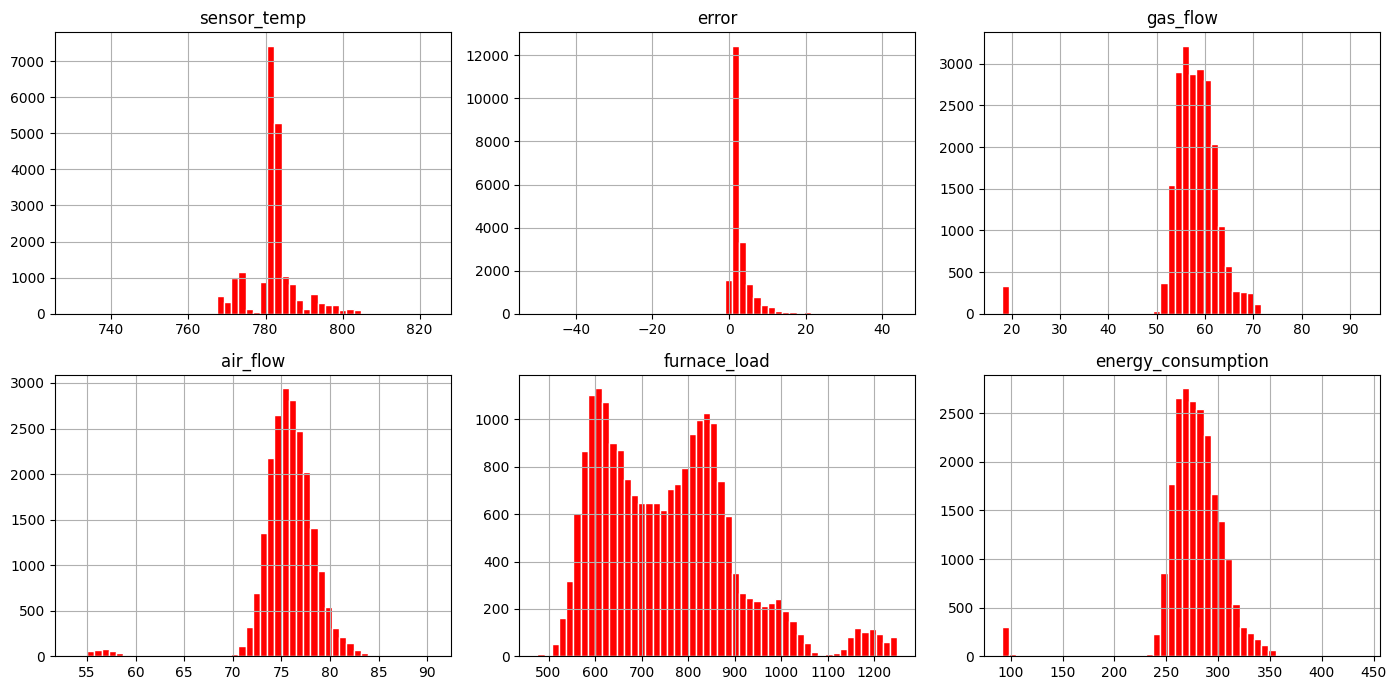

In [7]:
#Distribuciones
cols = ['sensor_temp', 'error', 'gas_flow', 'air_flow', 'furnace_load', 'energy_consumption']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), cols):
    df[col].hist(bins=50, ax=ax, color='r', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()

In [8]:
# Análisis de tiempo fuera de rango para sensor_temp (rango 760-800)
rango_min, rango_max = 760, 800

for turno in [1, 2, 3]:
    subset = df[df['turno'] == turno]['sensor_temp']
    fuera = ((subset < rango_min) | (subset > rango_max)).sum()
    pct = fuera / len(subset) * 100
    print(f"Turno {turno}: {pct:.1f}% del tiempo fuera de rango ({fuera:,} / {len(subset):,} registros)")

# Total general
total_fuera = ((df['sensor_temp'] < rango_min) | (df['sensor_temp'] > rango_max)).sum()
pct_total = total_fuera / len(df) * 100
print(f"\nTotal general: {pct_total:.1f}% fuera de rango ({total_fuera:,} / {len(df):,} registros)")

Turno 1: nan% del tiempo fuera de rango (0 / 0 registros)
Turno 2: nan% del tiempo fuera de rango (0 / 0 registros)
Turno 3: nan% del tiempo fuera de rango (0 / 0 registros)

Total general: 1.7% fuera de rango (366 / 21,600 registros)


/tmp/ipykernel_15325/3869538018.py:7: RuntimeWarning: invalid value encountered in scalar divide
  pct = fuera / len(subset) * 100


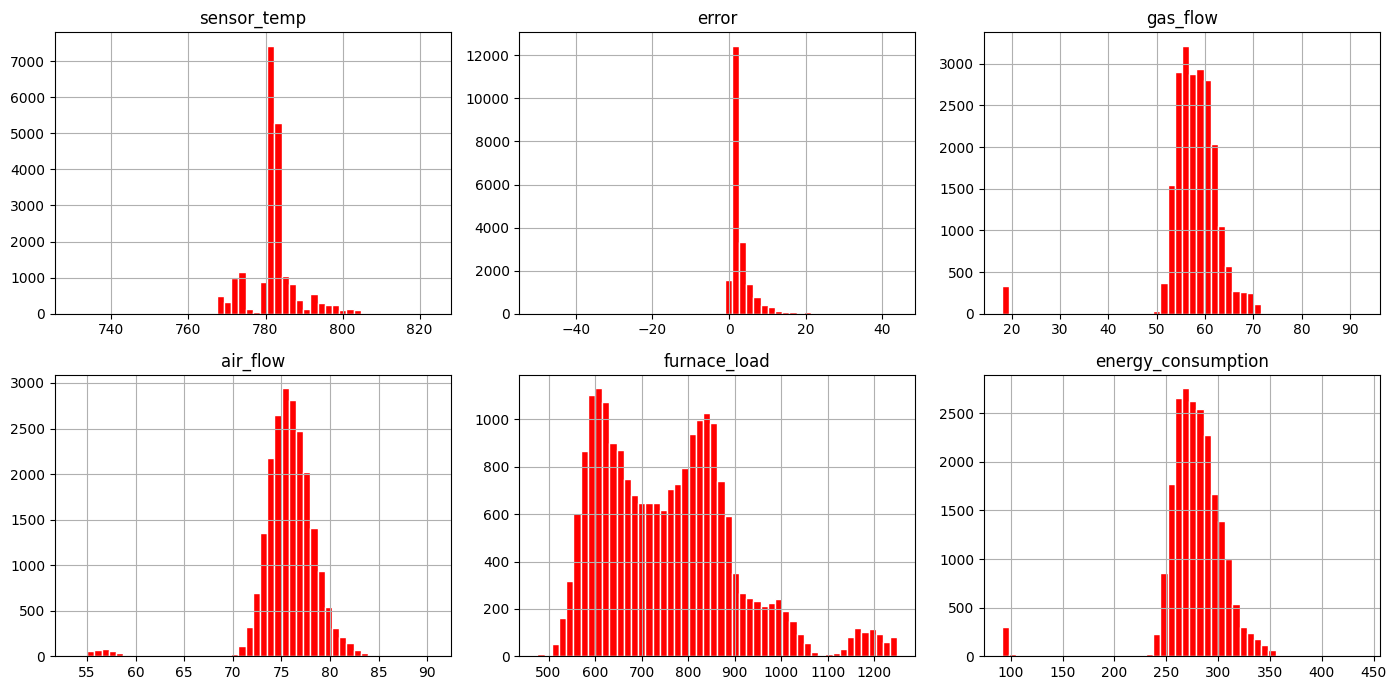

In [9]:
#Distribuciones
cols = ['sensor_temp', 'error', 'gas_flow', 'air_flow', 'furnace_load', 'energy_consumption']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), cols):
    df[col].hist(bins=50, ax=ax, color='r', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()

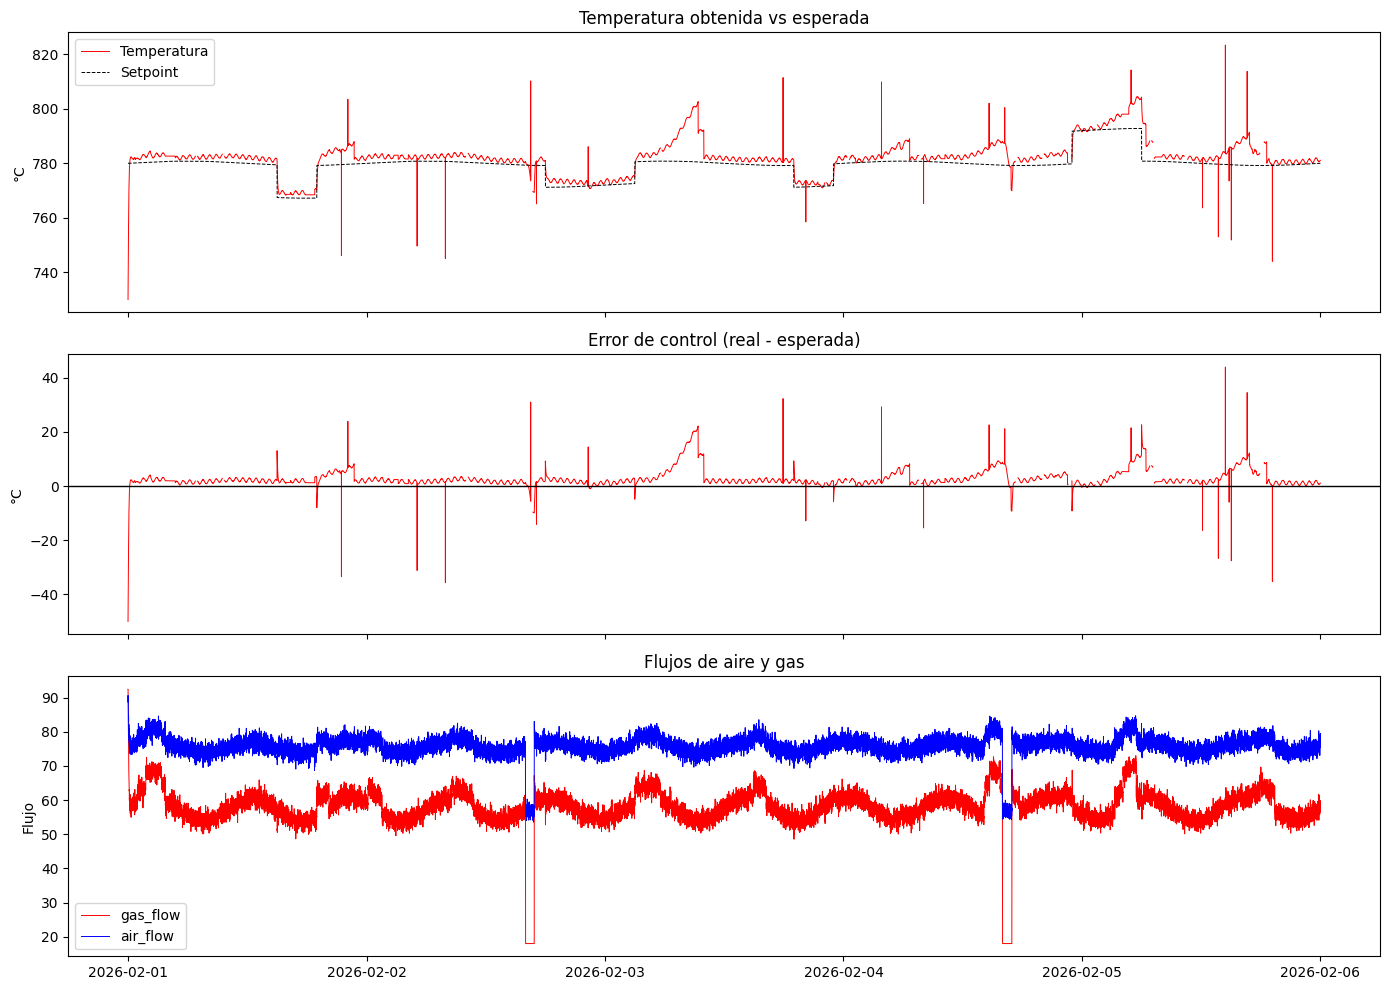

In [10]:
#Gráficas de temperatura esperada vs obtenida
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df['timestamp'], df['sensor_temp'], lw=0.7, label='Temperatura', color = 'r')
axes[0].plot(df['timestamp'], df['setpoint'], lw=0.7, ls='--', label='Setpoint', color = 'k')
axes[0].set_ylabel('°C')
axes[0].legend()
axes[0].set_title('Temperatura obtenida vs esperada')

axes[1].plot(df['timestamp'], df['error'], lw=0.7, color='red')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_ylabel('°C')
axes[1].set_title('Error de control (real - esperada)')

#Gráficas del flujo de aire y de gas
axes[2].plot(df['timestamp'], df['gas_flow'], lw=0.7, label='gas_flow', color='r')
axes[2].plot(df['timestamp'], df['air_flow'], lw=0.7, label='air_flow', color='b')
axes[2].set_ylabel('Flujo')
axes[2].legend()
axes[2].set_title('Flujos de aire y gas')

plt.tight_layout()

matriz de correlaciones

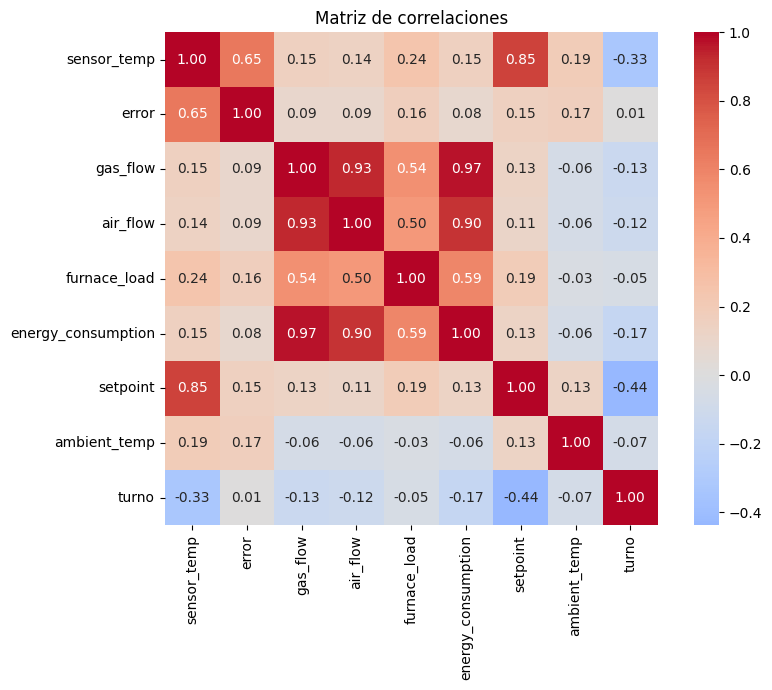

In [11]:
#Matriz de correlaciones
plt.figure(figsize=(9, 7))
corr = df[cols + ['setpoint', 'ambient_temp', 'turno']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de correlaciones')
plt.tight_layout()

In [12]:
#Métricas de error
e = df['error'].dropna()
dt = 20  #Segundos entre muestras

print(f'Error medio: {e.mean():.4f} °C')
print(f'Desviación estándar: {e.std():.4f} °C')
print(f'RMSE: {np.sqrt((e**2).mean()):.4f} °C')

Error medio: 2.7725 °C
Desviación estándar: 3.2463 °C
RMSE: 4.2690 °C


los turnos tendrán algo que ver?

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


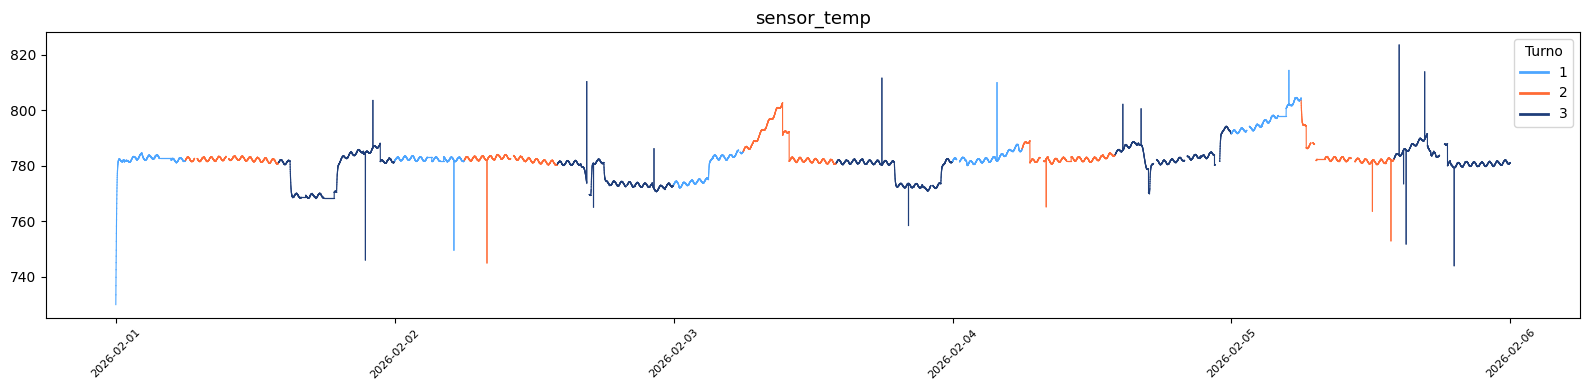

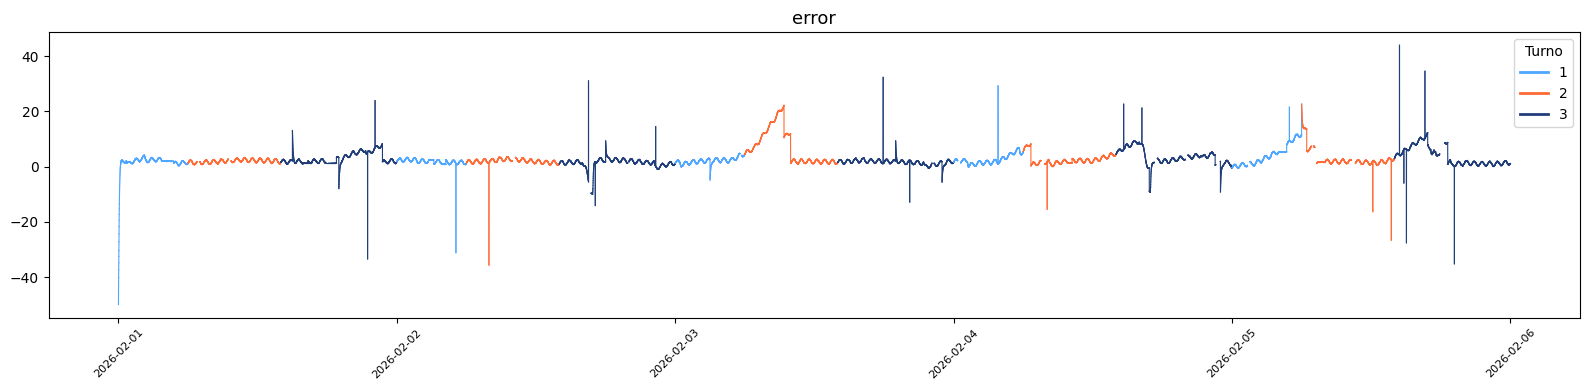

/tmp/ipykernel_15325/4225155137.py:33: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


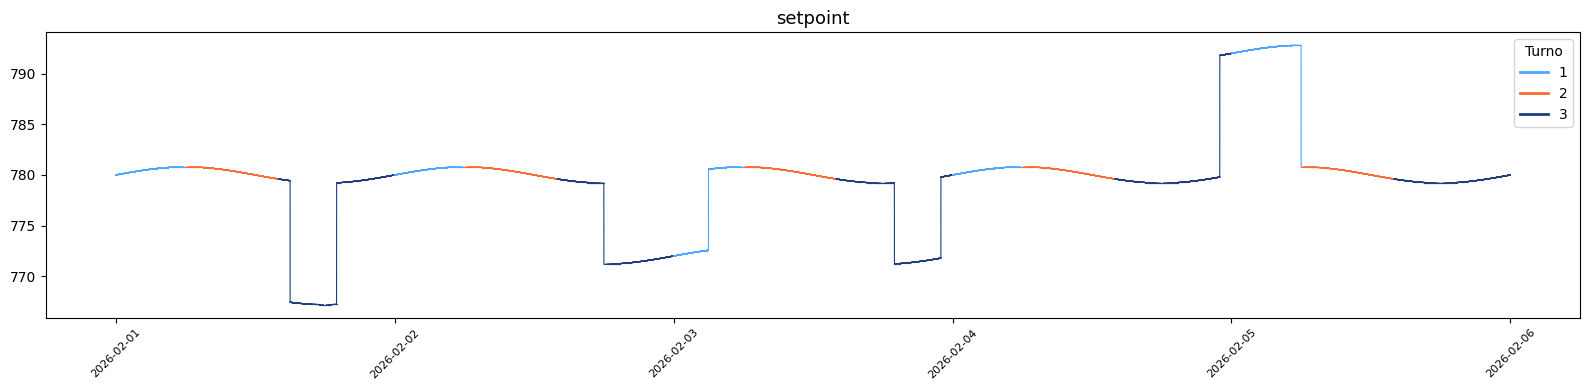

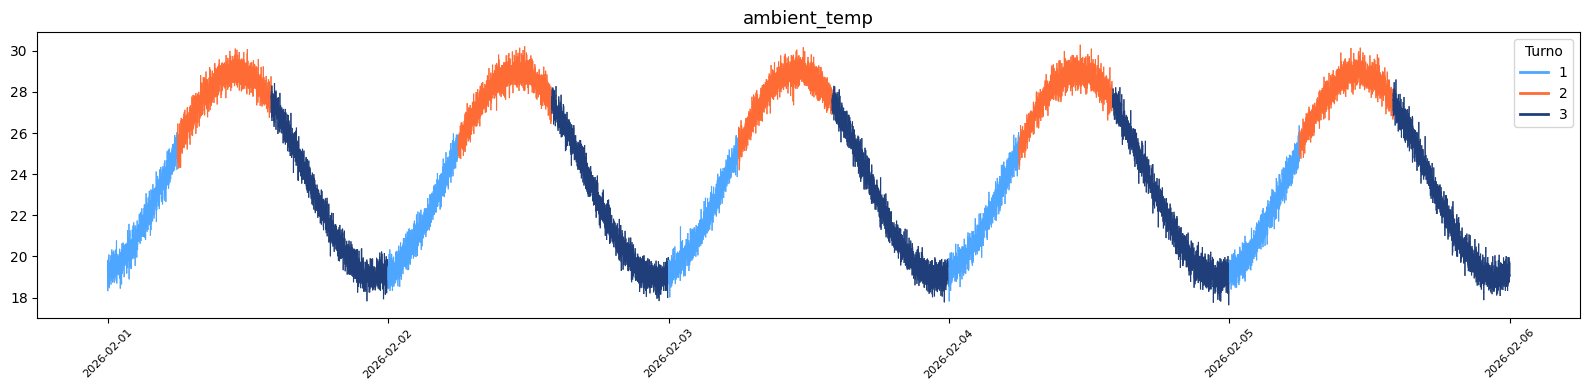

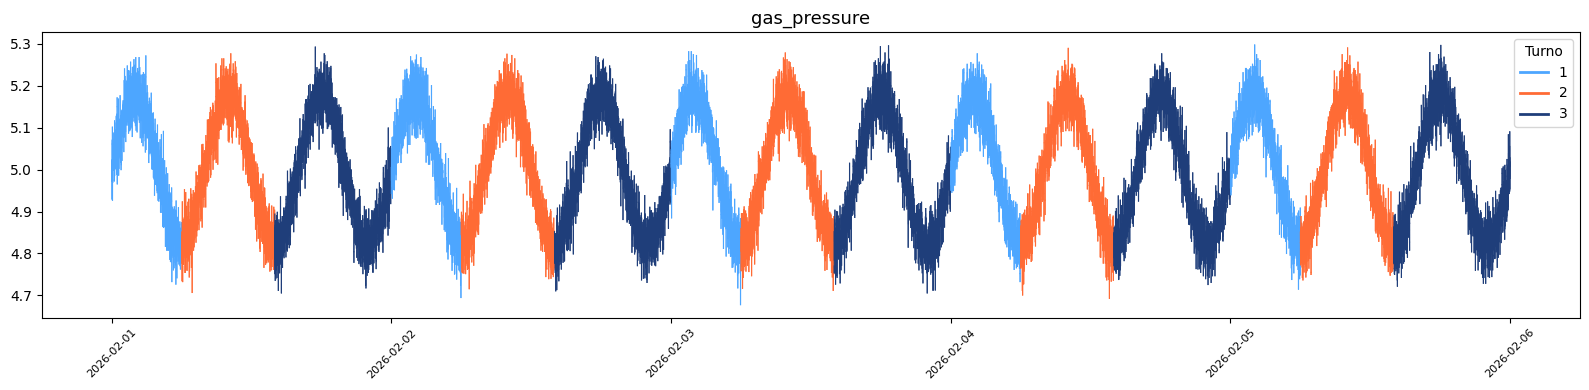

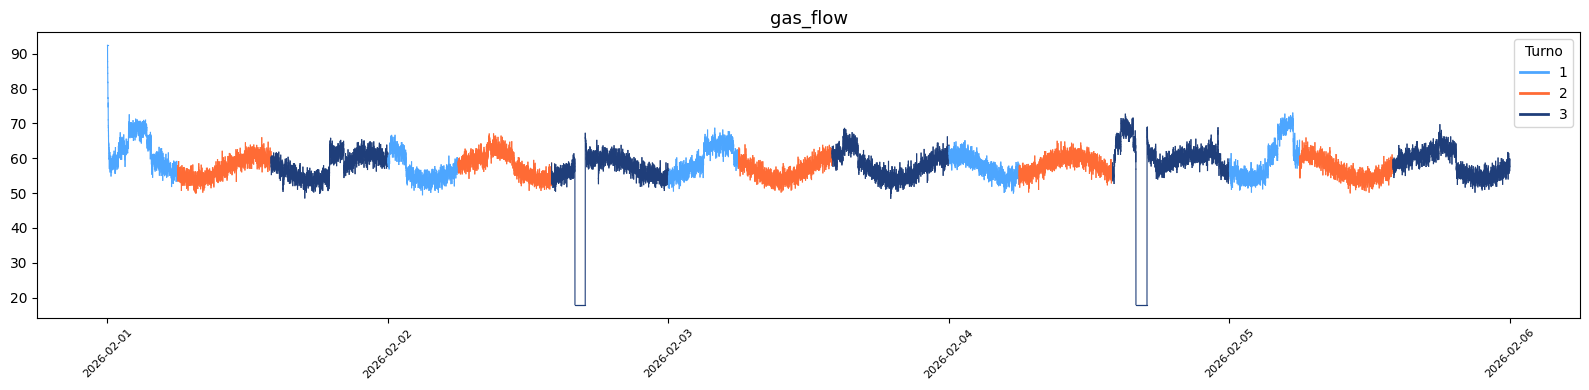

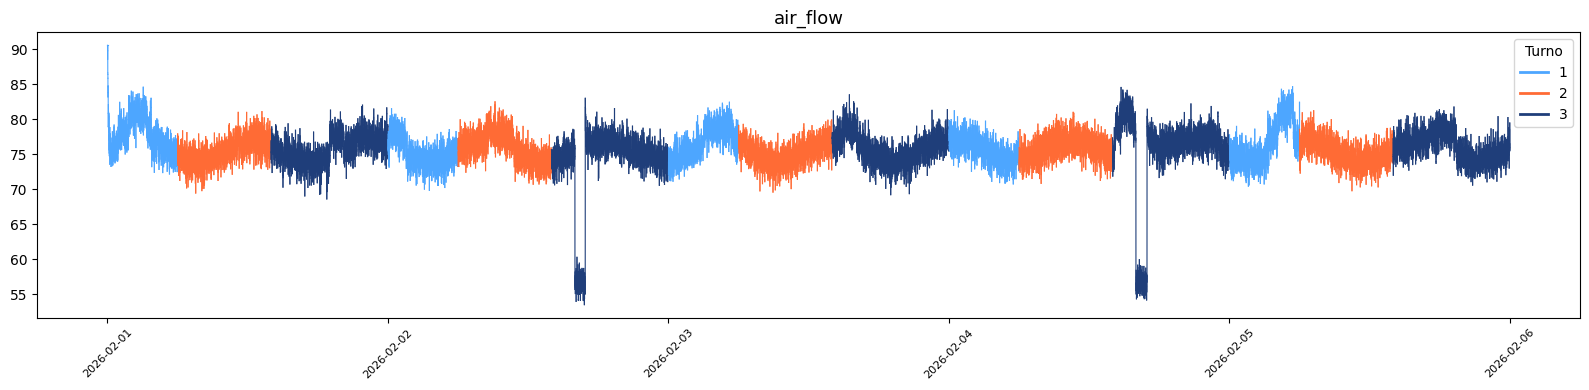

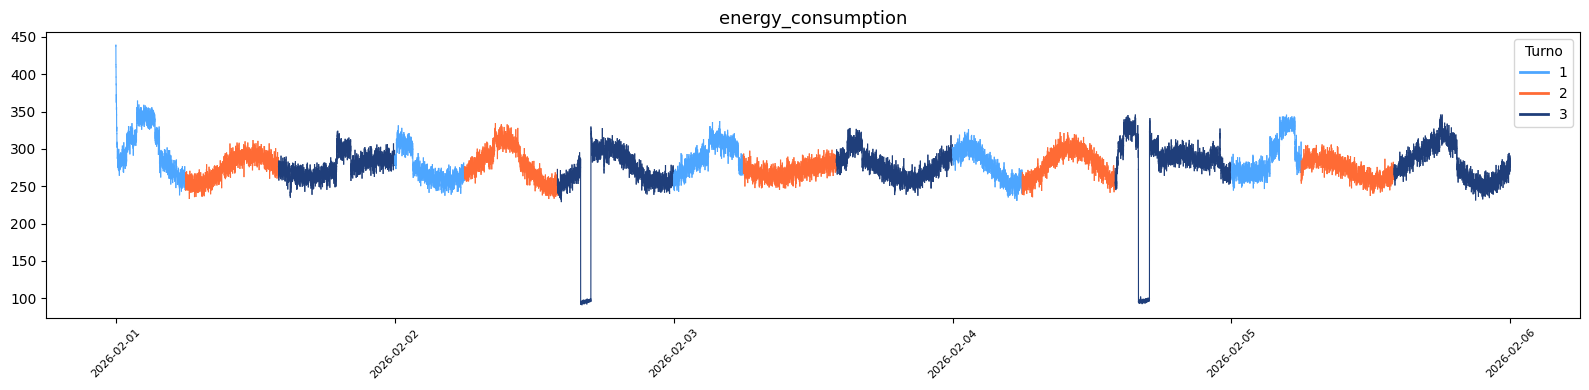

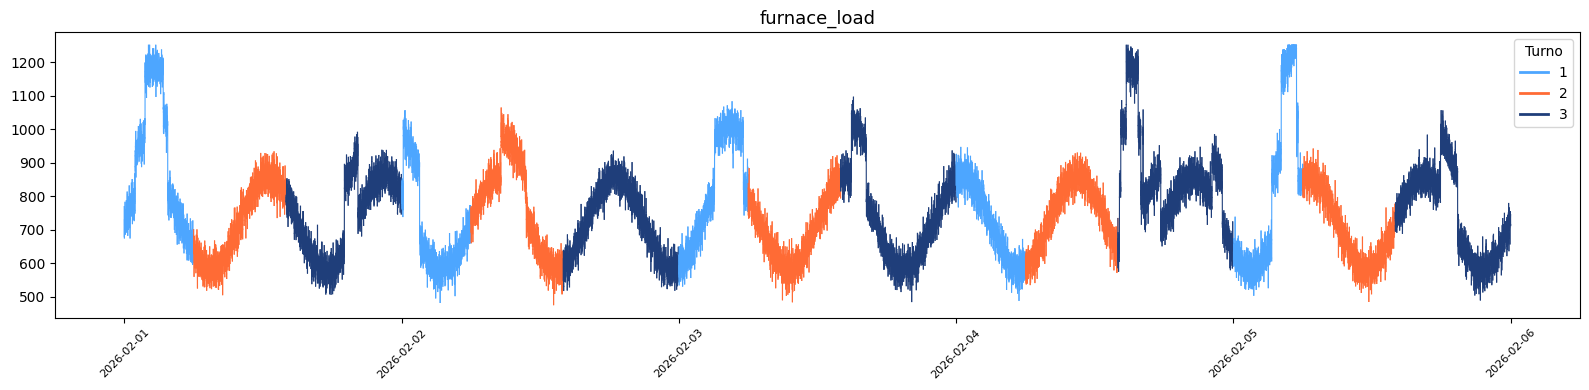

In [13]:
# 1 matutino
# 2 vespertino
# nocturno

colores = {
    '1':   '#4DA6FF',
    '2': '#FF6B35',
    '3':   '#1F3E7A'
}

variables = ['sensor_temp',  'error', 'setpoint', 'ambient_temp',
            'gas_pressure', 'gas_flow', 'air_flow', 'energy_consumption',
             'furnace_load'
            ]


for var in variables:
    fig, ax = plt.subplots(figsize=(16, 4))

    for i in range(len(df) - 1):
        turno = df['turno'].iloc[i]
        ax.plot(
            df['timestamp'].iloc[i:i+2],
            df[var].iloc[i:i+2],
            color=colores[turno],
            linewidth=0.8
        )

    leyenda = [Line2D([0], [0], color=c, linewidth=2, label=t) for t, c in colores.items()]
    ax.legend(handles=leyenda, title='Turno')
    ax.set_title(var, fontsize=13)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    plt.tight_layout()
    plt.show()

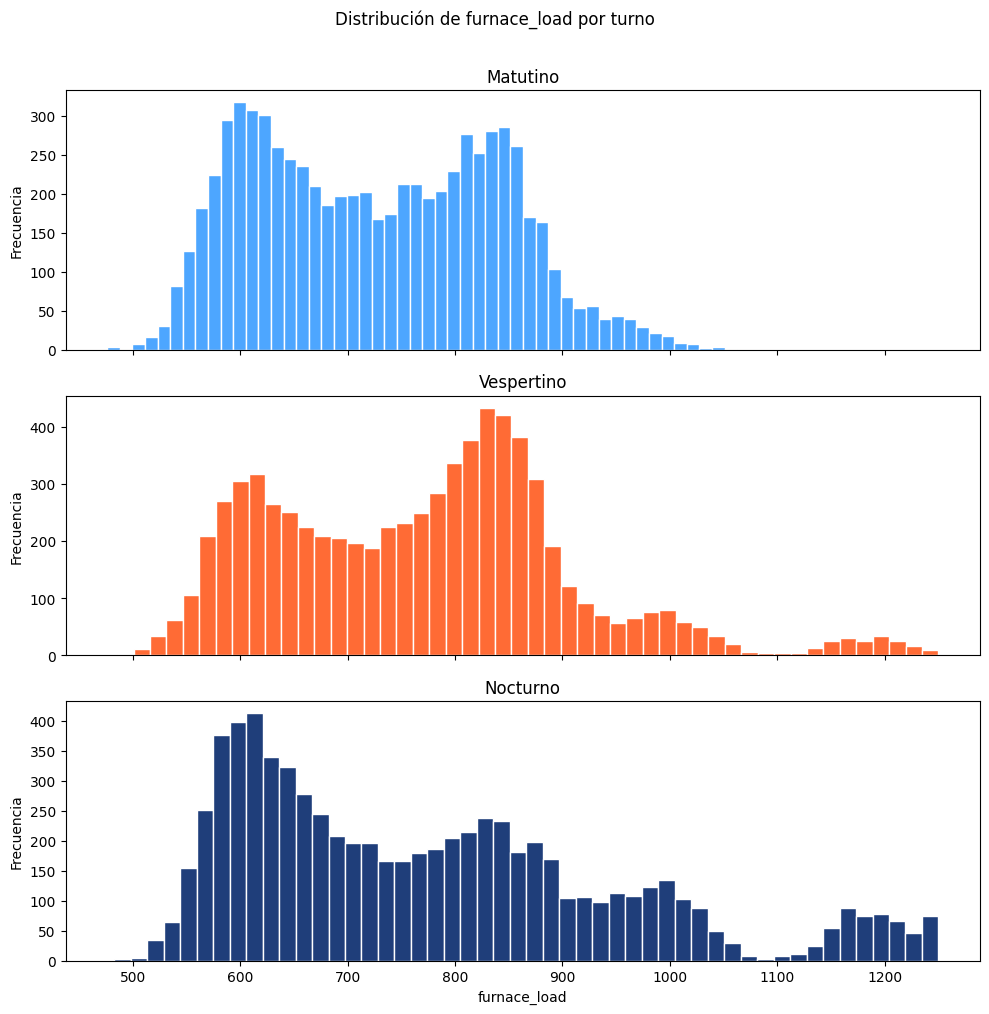

In [28]:
def asignar_turno(ts):
    h = ts.hour
    if h < 6: return 'Nocturno'
    elif h < 14: return 'Matutino'
    elif h < 22: return 'Vespertino'
    else: return 'Nocturno'

df['turno'] = df['timestamp'].apply(asignar_turno)

colores = {
    'Matutino':   '#4DA6FF',
    'Vespertino': '#FF6B35',
    'Nocturno':   '#1F3E7A'
}

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

for ax, (turno, color) in zip(axes, colores.items()):
    subset = df[df['turno'] == turno]['furnace_load']
    ax.hist(subset, bins=50, color=color, edgecolor='white')
    ax.set_title(turno)
    ax.set_ylabel('Frecuencia')

axes[-1].set_xlabel('furnace_load')
plt.suptitle('Distribución de furnace_load por turno', y=1.01)
plt.tight_layout()

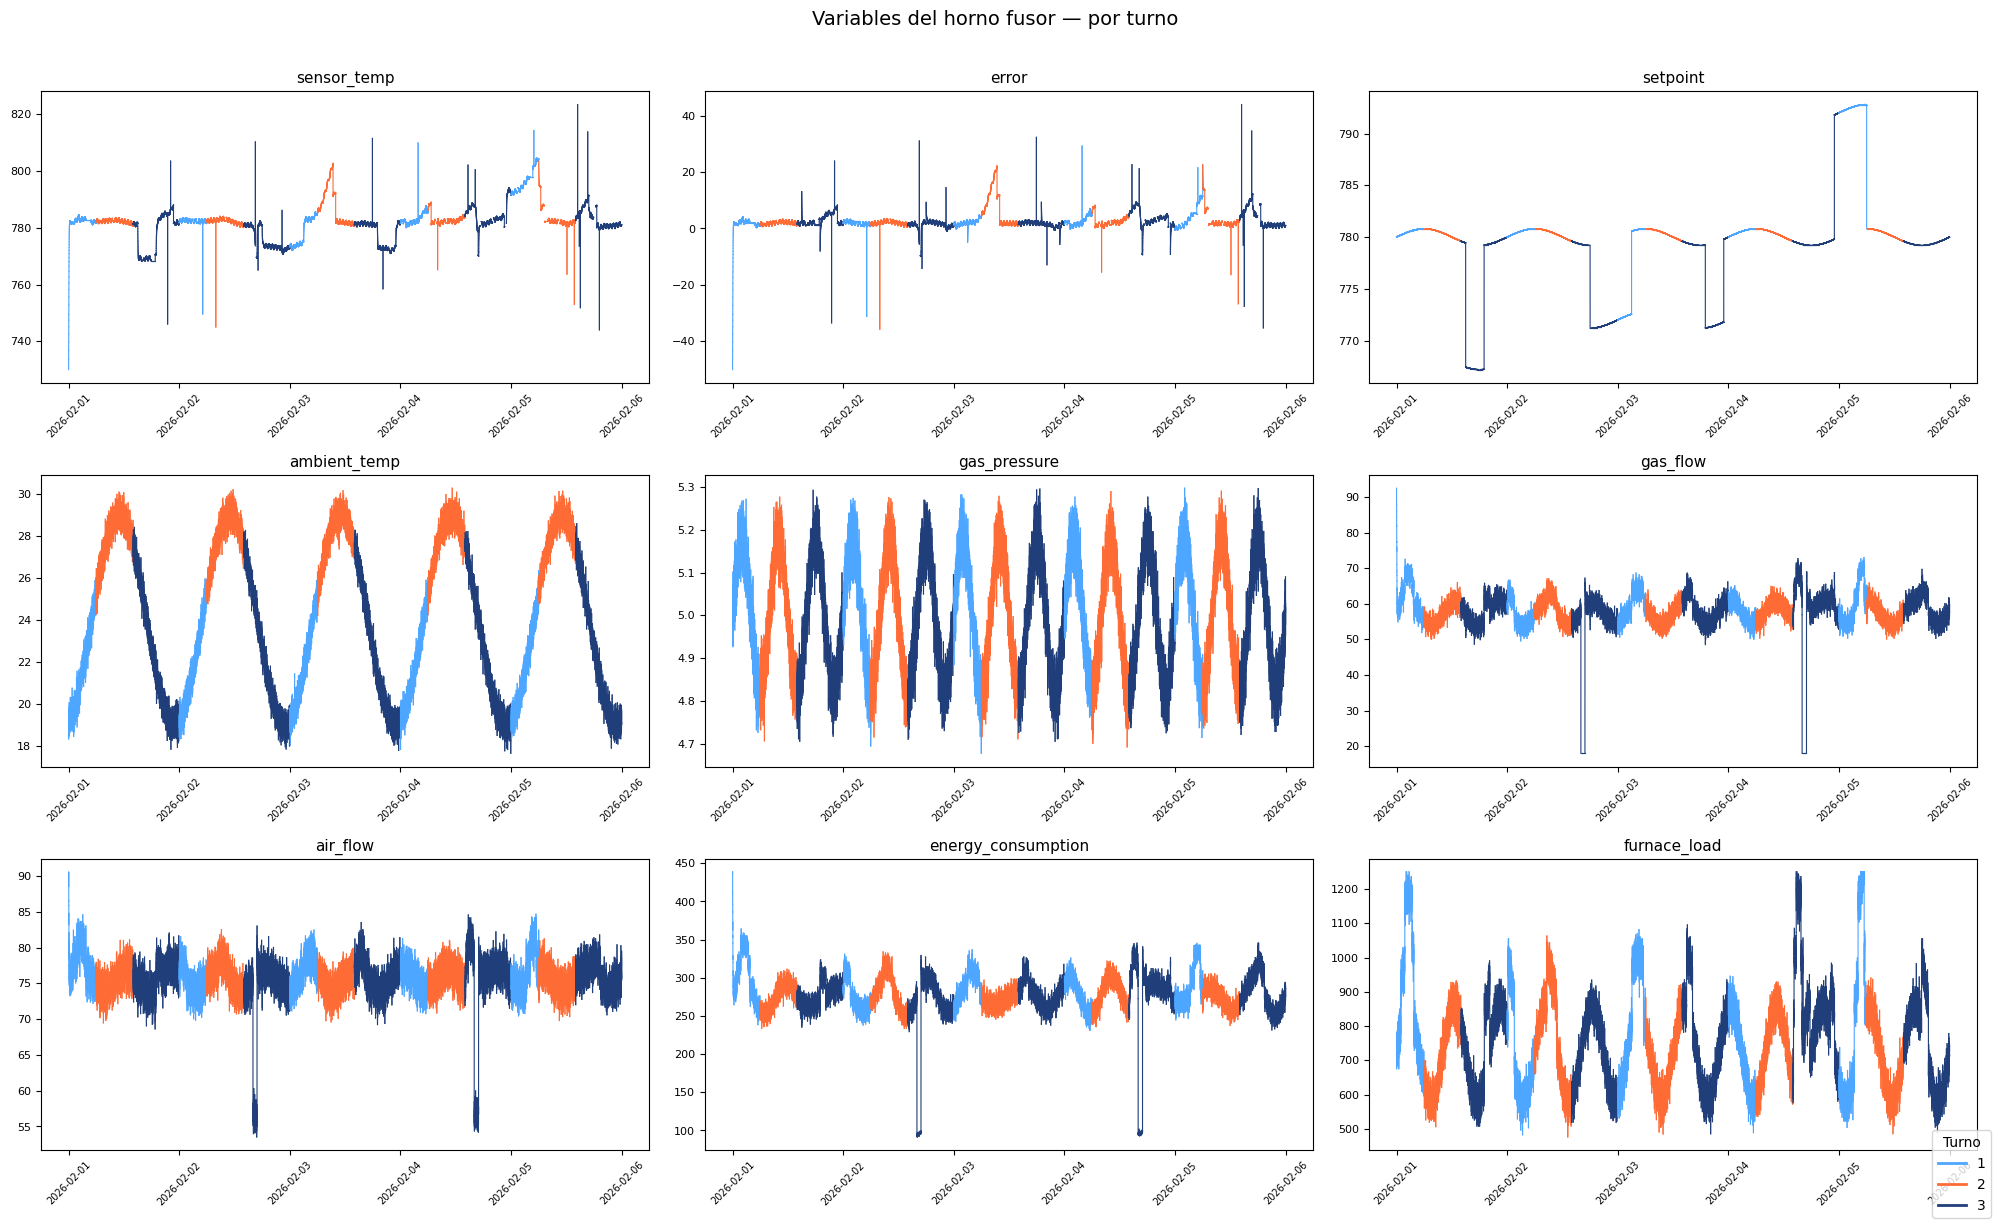

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()

for ax, var in zip(axes, variables):
    for i in range(len(df) - 1):
        turno = df['turno'].iloc[i]
        ax.plot(
            df['timestamp'].iloc[i:i+2],
            df[var].iloc[i:i+2],
            color=colores[turno],
            linewidth=0.8
        )
    ax.set_title(var, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=8)

# Leyenda global
from matplotlib.lines import Line2D
leyenda = [Line2D([0], [0], color=c, linewidth=2, label=t) for t, c in colores.items()]
fig.legend(handles=leyenda, loc='lower right', fontsize=10, title='Turno')

fig.suptitle('Variables del horno fusor — por turno', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

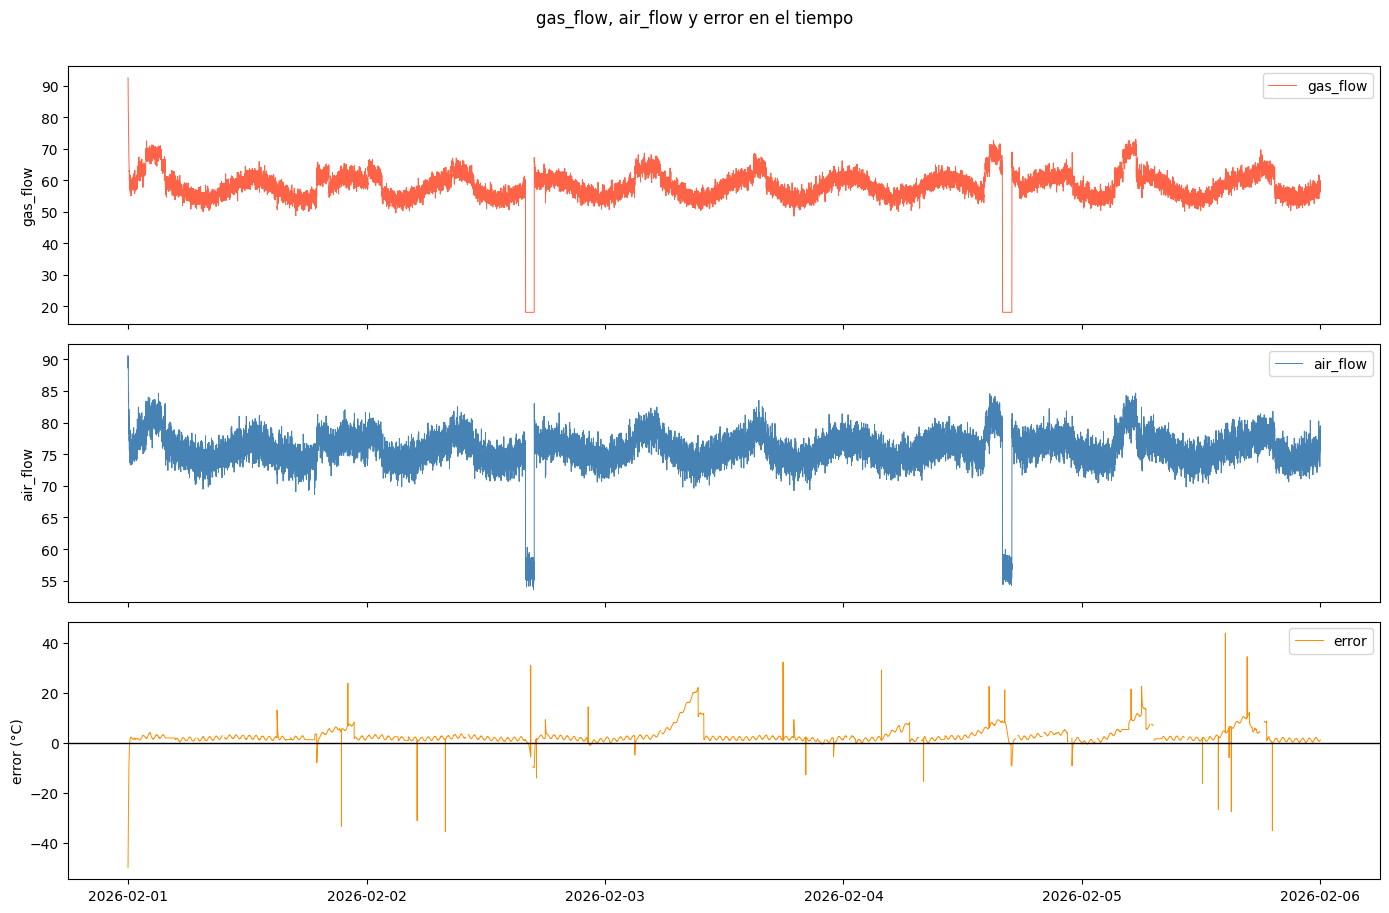

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df['timestamp'], df['gas_flow'], lw=0.7, color='tomato', label='gas_flow')
axes[0].set_ylabel('gas_flow')
axes[0].legend()

axes[1].plot(df['timestamp'], df['air_flow'], lw=0.7, color='steelblue', label='air_flow')
axes[1].set_ylabel('air_flow')
axes[1].legend()

axes[2].plot(df['timestamp'], df['error'], lw=0.7, color='darkorange', label='error')
axes[2].axhline(0, color='black', lw=1)
axes[2].set_ylabel('error (°C)')
axes[2].legend()

plt.suptitle('gas_flow, air_flow y error en el tiempo', y=1.01)
plt.tight_layout()